<a href="https://colab.research.google.com/github/lakshmivalsalan/machine-learning-fundamentals/blob/main/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **# ML: TASK‐01 Breast Cancer Classification**

## **Breast Cancer Classification**



In [ ]:
import pandas as pd

df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.shape

(569, 33)

### **Perform Basic Preprocessing**

In [ ]:
# Drop irrelevant columns
# 'id' is just a patient identifier and is not useful for prediction
# 'Unnamed: 32' is an empty column with all null values
df.drop(columns=['id','Unnamed: 32'], inplace=True)

# Verify the shape
df.shape

(569, 31)

### Check for nulls

In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


### Encode the target column

In [ ]:
# Encode 'diagnosis' : M (Malignant) = 1, B (Benign) = 0

df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

# verify the encoding worked correctly
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


ML models need numerical input and not strings. That's why we performed the encoding.

### Separate features and target

In [ ]:
# X contains all feature columns
# Y contains the target column

X = df.drop(columns=['diagnosis'])
Y = df['diagnosis']

### Train-Test split

In [ ]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)





Training size: (455, 30)
Testing size: (114, 30)


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# StandardScaler standardizes features to mean=0 and std=1

# creates StandardScaler object
scaler = StandardScaler()

# Fit on training data only, then transform both train and test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)










### **Train Models**



### **Support Vector Machine (SVM):**

In [ ]:
# imports the SVM classifier from sklearn.
# SVC stands for Support Vector Classifier
from sklearn.svm import SVC

# list of 4 kernels we want to tarin SVM with
kernels = ['linear','rbf','sigmoid','poly']

# create empty dictionary to store the trained models.
# we are training SVM 4 times - once for each kernel(linear, rbf, sigmoid, poly)
# each model produces a different trained model
svm_models = {}

# loops through each kernel line by line
for kernel in kernels:

  # creates a fresh SVM model for the current kernel
  svm = SVC(kernel = kernel, random_state=42)

  # train the model
  svm.fit(X_train,Y_train)

  # saves the model into the dictionary
  svm_models[kernel] = svm

  # confirmation message after each kernel is trained
  print(f"SVM with {kernel.upper()} kernel trained successfully.")





SVM with LINEAR kernel trained successfully.
SVM with RBF kernel trained successfully.
SVM with SIGMOID kernel trained successfully.
SVM with POLY kernel trained successfully.


The above cell trains four SVM models, one for each kernel:

Linear, RBF, Sigmoid, and Polynomial.

SVC (Support Vector Classifier) from sklearn is used for tarining. Each kernel learns a different decision boundary on the same training data.

The trained models are stored in a different dictionary (svm_models) for evaluation in the next step, avoiding the need to retrain them again.

### **K-Nearest Neighbors (KNN):**

### Elbow Method to find optimal K

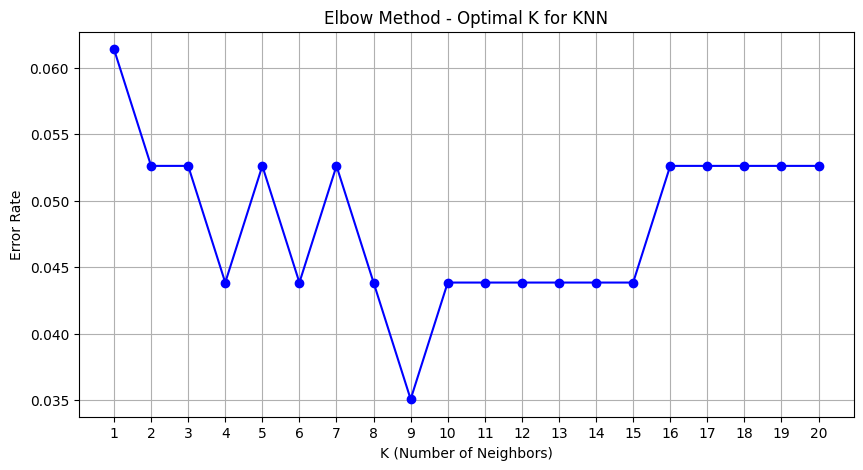

In [ ]:
# imports matplotlib for plotting the elbow curve
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# creates a range of k values from 1 to 20.These are the K values we'll test.
k_values = range(1,21)

# empty list to store the error rate for each K value
error_rates = []

# Loops through each K value one by one
for k in k_values:

  # creates a fresh KNN model with the current K.
  # n_neighbors = k tells KNN how many neighbors to look at
  knn = KNeighborsClassifier(n_neighbors=k)

  # Trains the KNN model on training data
  knn.fit(X_train, Y_train)

  # predicts on test data using the trained model
  y_pred = knn.predict(X_test)

  # calculates error rate and adds it to the list.
  # after the full loop, error_rates will have 20 values-one for each K
  error_rates.append(1 - accuracy_score(Y_test, y_pred))

# plot the albow curve
plt.figure(figsize=(10,5))

# plots k values on x-axis and error rates on y-axis.
# marker='o' puts a dot at each point
plt.plot(k_values,error_rates,marker='o',color='blue')

# sets the title and axis labels
plt.title('Elbow Method - Optimal K for KNN')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')

# forces the x-axis to show every K value (1 to 20) instead of skipping some.
plt.xticks(k_values)

# adds a background grid to make it easier to read the plot
plt.grid(True)

# displays the plot
plt.show()








The above cell uses the Elbow Method to find the optimal K for the KNN classifier.

KNN is trained 20 times, once for each K value from 1 to 20. For each K, the error rate (1 - accuracy) is calculated and stored. The error rates are then plotted against the K values to form the elbow curve.



From the elbow curve, K=9 gives the lowest error rate.

After K=9, the error rises and stabilizes.

Therefore, K=9 is selected as the optimum value for KNN.

### Train KNN with optimal K

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# from the elbow curve, pick the K where error rate is the lowest
optimal_k = 9

# train KNN with optimal K
knn = KNeighborsClassifier(n_neighbors = optimal_k)
knn.fit(X_train, Y_train)

print(f"KNN trianed sucessfully with K ={optimal_k}")

KNN trianed sucessfully with K =9


### **Model Evaluation**


Evaluate all SVM kernels

In [ ]:
# import accuracy score and confusion matrix from aklearn
from sklearn.metrics import accuracy_score, confusion_matrix

# print header to make output readable
# prints 60 equal signs as a separator
print("=" * 60)
print("SVM MODEL EVALUATION")
print("=" * 60)

# loops through the svm_models dictionary
# each iteration gives two values - kernel and model
for kernel, model in svm_models.items():

  # uses the current kernel's trained model to predict on test data
  Y_pred = model.predict(X_test)

  # compares actual labels (Y_test) with predicted labels (Y_pred) and stores the accuracy as acc
  acc = accuracy_score(Y_test, Y_pred)

  # generates the confusion matrix and stores it as cm
  cm = confusion_matrix(Y_test, Y_pred)

  # prints the current kernel name in uppercase.
  print(f"\nKernel: {kernel.upper()}")

  # prints accuracy upto 4 decimal places
  print(f"Accuracy score: {acc:.4f}")

  # prints the confusion matrix
  print(f"Confusion Matrix:\n{cm}")

  # prints a separator line between each kernel's output for readability
  print("=" * 40)



SVM MODEL EVALUATION

Kernel: LINEAR
Accuracy score: 0.9561
Confusion Matrix:
[[68  3]
 [ 2 41]]

Kernel: RBF
Accuracy score: 0.9825
Confusion Matrix:
[[71  0]
 [ 2 41]]

Kernel: SIGMOID
Accuracy score: 0.9561
Confusion Matrix:
[[68  3]
 [ 2 41]]

Kernel: POLY
Accuracy score: 0.8684
Confusion Matrix:
[[71  0]
 [15 28]]


From the output:

LINEAR : 0.9561

RBF : 0.9825

SIGMOID : 0.9561

POLY  : 0.8684

RBF is clearly the best kernel — highest accuracy at 98.25%.

POLY is the worst at 86.84%. LINEAR and SIGMOID gave the same result.

Reading the confusion matrix: (RBF is taken as example)

[[71 0]
[2 41]]



*   71 Benign correctly identified
*   41 Malignant correctly identified
*   2 Malignant cases were wrongly predicted as Benign  which is dangerous in medical context
*   0 Benign cases wrongly predicted as Malignant



### KNN MODEL EVALUATION

In [ ]:
print("=" * 60)
print("KNN MODEL EVALUATION")
print("=" * 60)

# Predict on test data
Y_pred_knn = knn.predict(X_test)

# Accuracy score
acc_knn = accuracy_score(Y_test, Y_pred_knn)

# Confusion Matrix
cm_knn = confusion_matrix(Y_test, Y_pred_knn)

print(f"\nK = {optimal_k}")
print(f"Accuracy Score: {acc_knn:.4f}")
print(f"Confusion Matrix:\n{cm_knn}")



KNN MODEL EVALUATION

K = 9
Accuracy Score: 0.9649
Confusion Matrix:
[[69  2]
 [ 2 41]]


Now we have all 5 results.

SVM-LINEAR : 95.61%
**SVM-RBF** : **98.25%**
SVM-SIGMOID : 95.61%
SVM-POLY : 86.84%
KNN (K=9) : 96.49%



*   Best overall is SVM with RBF kernel at 98.25%
*   KNN (96.49%) beats LINEAR and SIGMOID but loses to RBF
*  POLY is the worst performer

Also from a medical perspective, SVM-RBF is safer too. It only missed 2 Malignant cases whereas KNN also missed 2, but additionally misclassified 2 Benign as Malignant.




### **Model Comparison**

**1.Which model performed better:**

SVM with RBF kernel achieved the highest accuracy of 98.25%, outperforming KNN (K=9) which achieved 96.49%. Hence SVM is the better model for this dataset.

**2.Impact of fifferent SVM kernels:**



*   RBF kernel performed best (98.25%)
*   Linear and Sigmoid kernels gave equal accuracy (95.61%)
*   Polynomial kernel performed worst (86.84%), suggesting the data does not follow a polynomial boundary

**3.Effect of K value selection in KNN:**



*   The Elbow Method was used to determine the optimal K value
*   K=9 was selected as it gave the lowest error rate (~0.035) on the test data
*   Using a suboptimal K would have resulted in higher error rates, either due to overfitting (low K) or underfitting (high K)


____________________________________________________________________________________________________________________________________________




